In [1]:
!pip install easyocr -q

In [2]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.4 MB/s eta 0:00:00


In [3]:
import cv2
import os
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from collections import defaultdict
from PIL import Image
import zipfile
import shutil
import easyocr
import re
import json
from typing import Dict, Optional

In [4]:
# Инициализация OCR (русский + английский)
reader = easyocr.Reader(['ru', 'en'], gpu=False)

Using CPU. Note: This module is much faster with a GPU.


Progress: |██████████████████████████████████████████████████| 100.1% Complete

In [5]:
def preprocess_for_ocr_cont(image, debug=False):
   
    # 1. Увеличение контраста
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    #clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(4,4))
    #clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8,8))
    l_enhanced = clahe.apply(l)
    enhanced = cv2.merge([l_enhanced, a, b])
    enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)
    
    if debug:
        plt.figure(figsize=(15, 10))
        plt.subplot(2, 3, 1)
        plt.imshow(cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB))
        plt.title('2. Контраст')
        plt.axis('off')
    return enhanced
    

In [6]:
def preprocess_for_ocr_gray(image, debug=False):
   
    # 2. Преобразование в оттенки серого
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    if debug:
        plt.subplot(2, 3, 2)
        plt.imshow(gray, cmap='gray')
        plt.title('2. Оттенки серого')
        plt.axis('off')
    return gray

In [7]:
def preprocess_for_ocr_bin(image, debug=False):
   
    # 3. Бинаризация (Otsu + адаптивная)
    # Сначала Otsu для глобального порога
    _, binary_otsu = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Адаптивная бинаризация для локальных особенностей
    binary_adaptive = cv2.adaptiveThreshold(
        image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY, 11, 2
    )
    
    # Комбинируем
    binary = cv2.bitwise_or(binary_otsu, binary_adaptive)
    
    if debug:
        plt.subplot(2, 3, 3)
        plt.imshow(binary, cmap='gray')
        plt.title('3. Бинаризация')
        plt.axis('off')
    return binary

In [8]:
def preprocess_for_ocr_noise(image, debug=False):
   
    # 4. Удаление шума
    denoised = cv2.medianBlur(image, 1)
    denoised = cv2.GaussianBlur(denoised, (3, 3), 0)
    _, denoised = cv2.threshold(denoised, 127, 255, cv2.THRESH_BINARY)
    
    if debug:
        plt.subplot(2, 3, 4)
        plt.imshow(denoised, cmap='gray')
        plt.title('4. Удаление шума')
        plt.axis('off')
    return denoised

In [9]:
def preprocess_for_ocr_scale(image, debug=False):    
    # 6. Увеличение разрешения (опционально)
    scale_factor = 2
    h, w = image.shape[:2]
    upscaled = cv2.resize(image, (w * scale_factor, h * scale_factor), 
                          interpolation=cv2.INTER_CUBIC)
    
    if debug:
        plt.subplot(2, 3, 6)
        plt.imshow(upscaled, cmap='gray')
        plt.title('6. Увеличение разрешения')
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    
    return upscaled

(np.float64(-0.5), np.float64(430.5), np.float64(212.5), np.float64(-0.5))

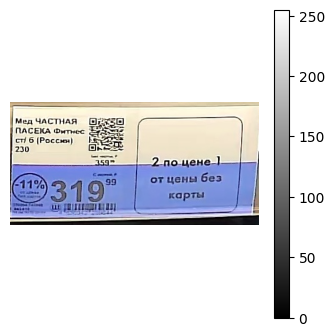

In [10]:
input_path = '/kaggle/input/datasets/mashamalyshkina/lenta-price-tags/price_tag_cropped0.jpg'
img_0 = cv2.imread(input_path)

fig = plt.figure(figsize=(4,4))
array = np.array(img_0)
plt.imshow(array, cmap='gray')
plt.colorbar()
plt.axis('off')

In [11]:
# Распознавание текста на вырезанном ценнике
result = reader.readtext(img_0, detail=0, paragraph=False)

print("Распознанный текст:")
for line in result:
    print(f"  {line}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Распознанный текст:
  Mu ЧА СТНАЯ
  Пл CEIА Фuтvtc
  Edl 6 Росскн |
  zJU
  2 по цене
  11%
  99
  от цены без
  319
  карты
  ш пЦяши


Распознанный текст:
  Мед ЧАСТНАЯ
  ПА СЕIА Фнтнсс
  6 [Росскн)
  2J0
  2 по цене
  99
  от цены без
  319
  карты


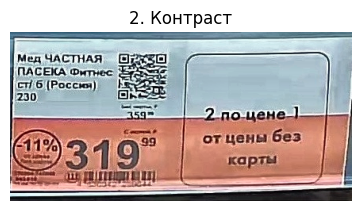

In [12]:
img = preprocess_for_ocr_cont(img_0, debug=True)
result = reader.readtext(img, detail=0, paragraph=False)

print("Распознанный текст:")
for line in result:
    print(f"  {line}")

Распознанный текст:
  Mu ЧА СТНАЯ
  Пл CEIА
  Фнтнtс
  6 [Росскн |
  zJU
  2 по цене ]
  11%
  99
  от цены без
  3195
  карты
  пшяшu


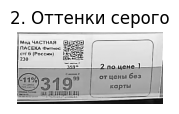

In [13]:
img = preprocess_for_ocr_gray(img_0, debug=True)
result = reader.readtext(img, detail=0, paragraph=False)

print("Распознанный текст:")
for line in result:
    print(f"  {line}")

Распознанный текст:
  #щ ЧЛСТНАя
  ПАUEKA 'Dunac
  EтI 6 /Росстн |
  ?JU
  17
  2 по-цене--
  от цаны без
  319
  картч
  пяЕШ
  пЦщ
   2з


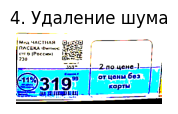

In [14]:
img = preprocess_for_ocr_noise(img_0, debug=True)
result = reader.readtext(img, detail=0, paragraph=False)

print("Распознанный текст:")
for line in result:
    print(f"  {line}")

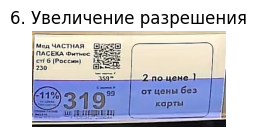

Распознанный текст:
  ЧА СТНАЯ
  ПДСЕIА ФОмтwtc
  Edl 6 [Россюн)
  2J0
  2 по -цене
  11%
  99
  от цены без
  319
  карты
  ШЯШ
  Mu


In [15]:
img = preprocess_for_ocr_scale(img_0, debug=True)
result = reader.readtext(img, detail=0, paragraph=False)

print("Распознанный текст:")
for line in result:
    print(f"  {line}")

In [16]:
def preprocess_for_ocr(image, debug=False):
    """
    Комплексная предобработка изображения для улучшения OCR
    
    Args:
        image: исходное изображение (BGR)
        debug: если True, показывает промежуточные результаты
    
    Returns:
        preprocessed: обработанное изображение (grayscale или color)
    """
    
    # # 1. Увеличение контраста
    # lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    # l, a, b = cv2.split(lab)
    # mean_brightness = np.mean(l)
    
    # # Автоматический подбор clipLimit
    # if mean_brightness < 60:        # очень тёмное
    #     clip_limit = 1.5
    #     tile_size = (4, 4)
    # elif mean_brightness < 100:     # тёмное
    #     clip_limit = 2.0
    #     tile_size = (6, 6)
    # elif mean_brightness < 140:     # нормальное
    #     clip_limit = 3.0
    #     tile_size = (8, 8)
    # elif mean_brightness < 180:     # светлое
    #     clip_limit = 2.5
    #     tile_size = (8, 8)
    # else:                           # очень светлое
    #     clip_limit = 2.0
    #     tile_size = (10, 10)
    # #clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    # clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    # l_enhanced = clahe.apply(l)
    # enhanced = cv2.merge([l_enhanced, a, b])
    # enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)
    
    # if debug:
    #     plt.figure(figsize=(15, 10))
    #     plt.subplot(2, 3, 1)
    #     plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    #     plt.title('1. Оригинал')
    #     plt.axis('off')
    
    # 2. Преобразование в оттенки серого
   # gray = cv2.cvtColor(enhanced, cv2.COLOR_BGR2GRAY)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    if debug:
        plt.subplot(2, 3, 2)
        plt.imshow(gray, cmap='gray')
        plt.title('2. Оттенки серого')
        plt.axis('off')
    
    # # 3. Бинаризация (Otsu + адаптивная)
    # # Сначала Otsu для глобального порога
    # _, binary_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # # Адаптивная бинаризация для локальных особенностей
    # binary_adaptive = cv2.adaptiveThreshold(
    #     gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
    #     cv2.THRESH_BINARY, 11, 2
    # )
    
    # # Комбинируем
    # binary = cv2.bitwise_or(binary_otsu, binary_adaptive)
    
    # if debug:
    #     plt.subplot(2, 3, 3)
    #     plt.imshow(binary, cmap='gray')
    #     plt.title('3. Бинаризация')
    #     plt.axis('off')
    
    # # 4. Удаление шума
    # denoised = cv2.medianBlur(binary, 3)
    # denoised = cv2.GaussianBlur(denoised, (3, 3), 0)
    # _, denoised = cv2.threshold(denoised, 127, 255, cv2.THRESH_BINARY)
    
    # if debug:
    #     plt.subplot(2, 3, 4)
    #     plt.imshow(denoised, cmap='gray')
    #     plt.title('4. Удаление шума')
    #     plt.axis('off')
    
    # # 5. Морфологические операции (закрытие дырок)
    # kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    # closed = cv2.morphologyEx(denoised, cv2.MORPH_CLOSE, kernel)
    
    # if debug:
    #     plt.subplot(2, 3, 5)
    #     plt.imshow(closed, cmap='gray')
    #     plt.title('5. Закрытие дырок')
    #     plt.axis('off')
    
    # 6. Увеличение разрешения (опционально)
    #scale_factor = 2
    scale_factor = 4
    # h, w = closed.shape[:2]
    # upscaled = cv2.resize(closed, (w * scale_factor, h * scale_factor), 
    #                       interpolation=cv2.INTER_CUBIC)
    h, w = gray.shape[:2]
    upscaled = cv2.resize(gray, (w * scale_factor, h * scale_factor), 
                          interpolation=cv2.INTER_CUBIC)
    
    if debug:
        plt.subplot(2, 3, 6)
        plt.imshow(upscaled, cmap='gray')
        plt.title('6. Увеличение разрешения')
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    
    return upscaled

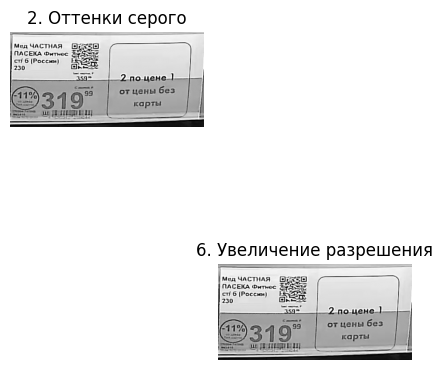

Распознанный текст:
  Mеn Ча СТНАЯ
  ПЛ СЕIА ФDuтtc
  E71 6 /Россю )
  2J0
  359
  2 по-цене
  119
  9g
  от цены без
  319
  карты
  шашш


In [17]:
img = preprocess_for_ocr(img_0, debug=True)
result = reader.readtext(img, detail=0, paragraph=False)

print("Распознанный текст:")
for line in result:
    print(f"  {line}")

In [18]:
class PriceTagParser:
    """Парсер ценников на основе структуры от магазина"""
    
    # Ожидаемые поля и их признаки
    FIELD_PATTERNS = {
        'product_name': r'[А-Я][а-я]+\s+[А-Я][а-я]+',  # слова с заглавных
        'price_without_card': r'(\d{1,4})\s*[рp]',
        'price_with_card': r'(\d{1,4})\s*(?:[рp]|руб)',
        'promo_price': r'(\d{1,3})\s*[рp](?:\s*[хx])?',
        'barcode': r'\d{13}',  # 13 цифр
        'unit_price': r'(\d{1,4})\s*[рp](?:\s*/\s*\d+[гкг])?',
        'discount': r'(\d+)%\s*скидка',
        'expiry_date': r'\d{2}\.\d{2}\.\d{4}'
    }
    
    # Коррекции распространённых ошибок OCR
    OCR_CORRECTIONS = {
        '0': 'О', 'Росскн': 'Россия', 'ЧАСТНАЯ': 'ЧАСТНАЯ',
        'Фнтнсс': 'ФИТНЕС', 'Мед': 'Мёд', 'ПА СЕIА': 'ПАССЕЯ'
    }
    
    @staticmethod
    def correct_ocr_text(text: str) -> str:
        """Исправление типичных ошибок OCR"""
        corrected = text
        for wrong, right in PriceTagParser.OCR_CORRECTIONS.items():
            corrected = corrected.replace(wrong, right)
        return corrected
    
    @staticmethod
    def parse(text_lines: list) -> Dict:
        """Извлечение структурированных данных из распознанного текста"""
        
        result = {
            'product_name': None,
            'price_without_card': None,
            'price_with_card': None,
            'promo_price': None,
            'barcode': None,
            'unit_price': None,
            'discount': None,
            'expiry_date': None,
            'raw_text': text_lines
        }
        
        full_text = ' '.join(text_lines)
        
        # 1. Поиск цен
        prices = re.findall(r'\b(\d{1,4})\b', full_text)
        if len(prices) >= 1:
            result['price_without_card'] = prices[0]
        if len(prices) >= 2:
            result['price_with_card'] = prices[1]
        if len(prices) >= 3:
            result['promo_price'] = prices[2]
        
        # 2. Поиск штрихкода
        barcode_match = re.search(PriceTagParser.FIELD_PATTERNS['barcode'], full_text)
        if barcode_match:
            result['barcode'] = barcode_match.group()
        
        # 3. Поиск названия (первая строка, если похожа на название)
        if text_lines:
            first_line = PriceTagParser.correct_ocr_text(text_lines[0])
            if re.match(r'[А-Я][а-я]+\s+[А-Я][а-я]+', first_line):
                result['product_name'] = first_line
            else:
                # Поиск названия по словам
                for line in text_lines[:3]:
                    corrected = PriceTagParser.correct_ocr_text(line)
                    if len(corrected) > 3 and corrected.isalpha():
                        result['product_name'] = corrected
                        break
        
        # 4. Поиск скидки
        discount_match = re.search(PriceTagParser.FIELD_PATTERNS['discount'], full_text, re.IGNORECASE)
        if discount_match:
            result['discount'] = discount_match.group(1)
        
        # 5. Поиск даты
        date_match = re.search(PriceTagParser.FIELD_PATTERNS['expiry_date'], full_text)
        if date_match:
            result['expiry_date'] = date_match.group()
        
        return result
    
    @staticmethod
    def to_dataframe(result: Dict):
        """Преобразование в pandas DataFrame"""
        import pandas as pd
        return pd.DataFrame([result])


# Использование
if __name__ == "__main__":
    ocr_results = [
        "Мед ЧАСТНАЯ",
        "ПА СЕIА Фнтнсс",
        "6 [Росскн)",
        "2J0",
        "2 по цене",
        "99",
        "от цены без",
        "319",
        "карты."
    ]
    
    parser = PriceTagParser()
    parsed = parser.parse(ocr_results)
    
    print("=== РЕЗУЛЬТАТ ПАРСИНГА ===")
    for key, value in parsed.items():
        if value and key != 'raw_text':
            print(f"{key}: {value}")
    
    # В виде таблицы
    df = parser.to_dataframe(parsed)
    print("\n=== ТАБЛИЦА ===")
    print(df.T)  # Транспонированная для удобства

=== РЕЗУЛЬТАТ ПАРСИНГА ===
price_without_card: 6
price_with_card: 2
promo_price: 99

=== ТАБЛИЦА ===
                                                                    0
product_name                                                     None
price_without_card                                                  6
price_with_card                                                     2
promo_price                                                        99
barcode                                                          None
unit_price                                                       None
discount                                                         None
expiry_date                                                      None
raw_text            [Мед ЧАСТНАЯ, ПА СЕIА Фнтнсс, 6 [Росскн), 2J0,...


In [19]:
class TemplateBasedParser:
    """Парсер на основе шаблонов ценников магазина"""
    
    def __init__(self, template_file=None):
        self.templates = self._load_templates(template_file)
    
    def _load_templates(self, template_file):
        """Загрузка шаблонов из JSON"""
        if template_file:
            with open(template_file, 'r', encoding='utf-8') as f:
                return json.load(f)
        
        # Встроенный шаблон на основе вашего примера
        return {
            "pattern": [
                {"field": "product_name", "type": "text", "position": "top"},
                {"field": "subtitle", "type": "text", "position": "second"},
                {"field": "price_without_card", "type": "price", "keywords": ["без карты", "обычная"]},
                {"field": "price_with_card", "type": "price", "keywords": ["по карте", "скидка"]},
                {"field": "promo_price", "type": "price", "keywords": ["акция", "по цене"]},
            ]
        }
    
    def parse(self, text_lines: list) -> Dict:
        """Парсинг на основе шаблона"""
        result = {
            'product_name': None,
            'price_without_card': None,
            'price_with_card': None,
            'promo_price': None,
        }
        
        full_text = ' '.join(text_lines).lower()
        
        # Поиск по ключевым словам
        for i, line in enumerate(text_lines):
            line_lower = line.lower()
            
            if 'без карты' in line_lower or 'от цены без' in line_lower:
                # Цена без карты — обычно следующая строка или число в текущей
                if i + 1 < len(text_lines):
                    price_match = re.search(r'\d+', text_lines[i + 1])
                    if price_match:
                        result['price_without_card'] = price_match.group()
            
            if 'по цене' in line_lower or 'акция' in line_lower:
                if i + 1 < len(text_lines):
                    price_match = re.search(r'\d+', text_lines[i + 1])
                    if price_match:
                        result['promo_price'] = price_match.group()
            
            # Название товара
            if not result['product_name'] and len(line) > 5 and line[0].isupper():
                result['product_name'] = line
        
        return result


# Использование
parser = TemplateBasedParser()
parsed = parser.parse([
    "Мёд ФИТНЕС",
    "ЧАСТНАЯ ПАССЕЯ",
    "319",
    "2 по цене 99",
    "от цены без 319"
])

print(parsed)

{'product_name': 'Мёд ФИТНЕС', 'price_without_card': None, 'price_with_card': None, 'promo_price': '319'}


In [20]:
def process_price_tag_to_table(image_path, ocr_processor, parser):
    """Полный цикл: изображение → OCR → парсинг → таблица"""
    
    # 1. OCR распознавание
    texts = ocr_processor.process_image(image_path)
    text_lines = [item['text'] for item in texts]
    
    print("=== Распознанный текст ===")
    for line in text_lines:
        print(f"  {line}")
    
    # 2. Парсинг в структуру
    parsed = parser.parse(text_lines)
    
    # 3. Создание таблицы (DataFrame)
    import pandas as pd
    df = pd.DataFrame([parsed])
    
    # 4. Сохранение результатов
    df.to_csv('price_tag_result.csv', index=False)
    print("\n=== Результат сохранён в price_tag_result.csv ===")
    
    return df



In [21]:
def process_price_tag(image_path, reader):
    result = reader.readtext(image_path, detail=0, paragraph=False)
    print("Распознанный текст:")
    for line in result:
        print(f"  {line}")
    return result

# Запуск
text_lines = process_price_tag('/kaggle/input/datasets/mashamalyshkina/lenta-price-tags/price_tag_cropped0.jpg', reader)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Распознанный текст:
  Mu ЧАСТНАЯ
  Пл CEIА
  Фнтнес
  [Росскн |
  zJU
  2 по цене ]
  11%
  99
  от цены без
  319
  карты
  шлшпяшu


In [22]:
def process_price_tag_to_table(image_path, reader, parser):
    """Полный цикл: изображение → OCR → парсинг → таблица"""
    
    # OCR распознавание
    texts = process_price_tag(image_path, reader)
    parsed = parser.parse(texts)
    
    #  Создание таблицы (DataFrame)
    import pandas as pd
    df = pd.DataFrame([parsed])
    
    #  Сохранение результатов
    df.to_csv('price_tag_result.csv', index=False)
    print("\n=== Результат сохранён в price_tag_result.csv ===")
    
    return df



In [23]:
process_price_tag_to_table('/kaggle/input/datasets/mashamalyshkina/lenta-price-tags/price_tag_cropped0.jpg',
                          reader,
                          parser)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Распознанный текст:
  Mu ЧАСТНАЯ
  Пл CEIА
  Фнтнес
  [Росскн |
  zJU
  2 по цене ]
  11%
  99
  от цены без
  319
  карты
  шлшпяшu

=== Результат сохранён в price_tag_result.csv ===


,product_name,price_without_card,price_with_card,promo_price
0,Mu ЧАСТНАЯ,319,None,11


In [24]:
import cv2
from ultralytics import YOLO
import easyocr
import pandas as pd
import numpy as np
from collections import deque

class PriceTagTracker:
    def __init__(self, yolo_model_path, ocr_lang='ru', 
                 time_window=2.0, iou_threshold=0.5):
        """
        time_window: временное окно (сек) для объединения дубликатов
        iou_threshold: порог пересечения bounding box для группировки
        """
        self.model = YOLO(yolo_model_path)
        self.reader = easyocr.Reader([ocr_lang, 'en'], gpu=False)
        self.time_window = time_window
        self.iou_threshold = iou_threshold
        
    def calculate_iou(self, box1, box2):
        """Вычисление IoU (пересечение / объединение) двух bounding box"""
        x1_1, y1_1, x2_1, y2_1 = box1
        x1_2, y1_2, x2_2, y2_2 = box2
        
        # Пересечение
        xi1 = max(x1_1, x1_2)
        yi1 = max(y1_1, y1_2)
        xi2 = min(x2_1, x2_2)
        yi2 = min(y2_1, y2_2)
        
        if xi2 <= xi1 or yi2 <= yi1:
            return 0.0
        
        intersection = (xi2 - xi1) * (yi2 - yi1)
        box1_area = (x2_1 - x1_1) * (y2_1 - y1_1)
        box2_area = (x2_2 - x1_2) * (y2_2 - y1_2)
        union = box1_area + box2_area - intersection
        
        return intersection / union if union > 0 else 0.0
    
    def is_duplicate(self, new_det, existing_dets, current_time):
        """Проверка, является ли детекция дубликатом существующей"""
        for det in existing_dets:
            # Проверка по времени
            if current_time - det['timestamp'] > self.time_window:
                continue
            
            # Проверка по IoU
            iou = self.calculate_iou(new_det['bbox'], det['bbox'])
            if iou > self.iou_threshold:
                return True
        return False
    
    def process_video(self, video_path, frame_skip=5):
        cap = cv2.VideoCapture(video_path)
        fps = int(cap.get(cv2.CAP_PROP_FPS))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        frame_count = 0
        unique_tags = []  # Список уникальных ценников
        recent_dets = deque(maxlen=30)  # Последние детекции для сравнения
        
        print(f"Всего кадров: {total_frames}")
        print(f"Обработка каждого {frame_skip}-го кадра...")
        
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            
            frame = cv2.rotate(frame, cv2.ROTATE_90_COUNTERCLOCKWISE)
            
            if frame_count % frame_skip == 0:
                current_time = frame_count / fps
                
                # Детекция на кадре
                results = self.model.predict(frame, conf=0.25, verbose=False)
                
                if len(results[0].boxes) > 0:
                    for box in results[0].boxes:
                        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
                        confidence = float(box.conf[0])
                        
                        # Вырезаем ценник для OCR
                        price_tag = frame[y1:y2, x1:x2]
                        if price_tag.size > 0:
                            ocr_result = self.reader.readtext(price_tag, detail=0, paragraph=False)
                            text = ' '.join(ocr_result) if ocr_result else ''
                        else:
                            text = ''
                        
                        new_detection = {
                            'bbox': (x1, y1, x2, y2),
                            'confidence': confidence,
                            'text': text,
                            'frame': frame_count,
                            'timestamp': current_time
                        }
                        
                        # Проверка на дубликат
                        if not self.is_duplicate(new_detection, recent_dets, current_time):
                            unique_tags.append(new_detection)
                            recent_dets.append(new_detection)
                            
                            print(f"✅ Новый ценник на {current_time:.1f}с: {text[:50]}")
            
            frame_count += 1
            if frame_count % 500 == 0:
                print(f"Обработано: {frame_count}/{total_frames} кадров, найдено ценников: {len(unique_tags)}")
        
        cap.release()
        print(f"\n Итого уникальных ценников: {len(unique_tags)}")
        
        return unique_tags
    
    def to_dataframe(self, tags):
        """Преобразование в DataFrame"""
        rows = []
        for tag in tags:
            rows.append({
                'timestamp': tag['timestamp'],
                'frame': tag['frame'],
                'confidence': tag['confidence'],
                'text': tag['text'],
                'bbox_x1': tag['bbox'][0],
                'bbox_y1': tag['bbox'][1],
                'bbox_x2': tag['bbox'][2],
                'bbox_y2': tag['bbox'][3]
            })
        return pd.DataFrame(rows)


# Использование
tracker = PriceTagTracker(
    yolo_model_path='/kaggle/input/notebooks/mashamalyshkina/lenta-yolo-train/runs/detect/train/weights/best.pt',
    ocr_lang='ru',
    #time_window=2.0,    # 2 секунды между кадрами для группировки
    time_window=4.0,    # 2 секунды между кадрами для группировки
    #iou_threshold=0.5   # 50% пересечения = тот же ценник
    iou_threshold=0.3   # 30% пересечения = тот же ценник
)

unique_tags = tracker.process_video(
    video_path='/kaggle/input/datasets/mashamalyshkina/lenta-test-video/26_2-10.mp4',
    frame_skip=3  # каждый 3-й кадр
)

df = tracker.to_dataframe(unique_tags)
print(f"\n📊 Результат: {len(df)} уникальных ценников")
print(df.head())

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Using CPU. Note: This module is much faster with a GPU.


Всего кадров: 613
Обработка каждого 3-го кадра...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


✅ Новый ценник на 0.0с: = € _ =; ц - = F ~Y= z =7 WOW ' 25: 1699s находка
✅ Новый ценник на 0.0с: ===  ~,e  5 26- 3995 2 =
✅ Новый ценник на 0.0с: ёгс ;re ' ~ 'e F 2u  : 67gs
✅ Новый ценник на 0.0с: 599
✅ Новый ценник на 0.0с: (д 1s_ 5_- 3zae-e Ст цетн 6аз 499 вср
✅ Новый ценник на 0.0с: 699
✅ Новый ценник на 0.0с: 
✅ Новый ценник на 0.0с: 
✅ Новый ценник на 0.0с: 70
✅ Новый ценник на 0.0с: 719
✅ Новый ценник на 0.0с: 5ae 1499 Cn
✅ Новый ценник на 0.0с: 
✅ Новый ценник на 0.3с: 599
✅ Новый ценник на 0.3с: 699
✅ Новый ценник на 0.3с: 21: 6795
✅ Новый ценник на 0.3с: 25 3995
✅ Новый ценник на 0.3с: 719
✅ Новый ценник на 0.3с: 
✅ Новый ценник на 0.3с: -1299=
✅ Новый ценник на 0.3с: 1799
✅ Новый ценник на 0.3с: 7z9
✅ Новый ценник на 0.3с: 
✅ Новый ценник на 0.6с: 1299
✅ Новый ценник на 0.6с: 399
✅ Новый ценник на 0.6с: 699
✅ Новый ценник на 0.6с: 
✅ Новый ценник на 0.6с: 
✅ Новый ценник на 0.6с: (г 3 7о_це-€ сI Ссз 499 сяэz e _
✅ Новый ценник на 0.6с: 7
✅ Новый ценник на 0.6с: 719
✅ Новый 